## <font color=#0099CC>mIAx - Taller Renta Fija - ANÁLISIS CARTERA DE RENTA FIJA</font>

En esta práctica, desarrollaremos un análisis relativamente exahustivo de un universo de Renta Fija, en concreto, de bonos corporativos. Además, construiremos y analizaremos varias carteras. 

Para ello, contaremos con la siguiente información almacenada en la carpeta *data*:
- Universo de bonos, con sus características esenciales (fichero *universo.csv*)
- Histórico de precios de cierre del universo de bonos anterior (fichero *precios_historicos_universo.csv*)
- Curva de tipos de interés €STR (fichero *curvaESTR.csv*)
- Histórico de precios de otros índices que nos serán de utilidad (fichero *precios_historicos_varios*):
    - Índices de crédito: ITRAXX Main y ITRAXX XOVER. Serán útiles para la cobertura del riesgo de crédito.
    - Futuros sobre el *Schatz* (DU1), *BOBL* (OE1) y *BUND* (RX1). Serán útiles para la cobertura de los tipos de interés.
    - Índice de crédito *RECMTREU*, que valdría como benchmark de las carteras que construyamos.

No necesariamente se usará toda toda la información

En lineas generales, estos son los ejercicios que completaremos, aunque los detallaremos más en cada apartado:
1. Análisis de datos. En esta sección, haremos un análisis de la información que tenemos de cada bono y lo que significa. Asimismo, haremos los tratamientos y limpieza que necesitemos para luego poder usarlos.
2. Valoración de los bonos del universo utilizando la curva de descuento y bajo ciertas asunciones. Comparación de estos precios con los precios de mercado.
3. Cálculo del spread que pagan los bonos sobre la curva.
4. Cálculo de *yield*, duración y convexidad.
5. Contrucción de una cartera equiponderada con todos los bonos del universo. Contraste con el benchmark (os proponemos el índice RECMTREU para el que os hemos dado los precios) y backtest de la estrategia. ¡OJO! El índice es *Total Return*.
6. Tienes el mandato de construir una cartera de como máximo **20** bonos corporativos con ese universo y una serie de restricciones y, claro, maximizando la rentabilidad total de la cartera:
    - La duración de la cartera no debe superar los 3 años
    - La exposición a emisiones HY no puede superar el 10% de la cartera
    - No puedes invertir en deuda subordinada
    - No se puede invertir en emisiones de tamaño igual o inferior a 500 millones
    - No se puede invertir más de un 10% del capital en una misma emisión
    - No puede haber más de un 15% de concentración en un mismo emisor
    (¡OJO! No estamos teniendo en cuenta en este ejercicio si hubiera un mínimo de inversión, lo cuál sería un dato relevante tener en cuenta en un caso real)

    6.1. Constrúyela a fecha de hoy

    6.2. Teniendo en cuenta la naturaleza que nos están pidiendo para la cartera, ¿añadirías alguna otra restricción?

    6.3. ¿Cómo medirías el riesgo de crédito de la cartera?

    6.4. ¿Cómo medirías el riesgo de liquidez de la cartera?

    6.5. Describe cómo habría que hacer el backtest de esta cartera
7. Ahora, se te pide que cubras la exposición de la cartera a los tipos de interés. Con la información que tienes, ¿cómo lo harías?
8. ¿Y si quisieras cubrir total o parcialmente el riesgo de crédito? Usa de nuevo la información que tienes.
9. ¿Cómo construirías tu cartera? ¿Se te ocurre alguna estrategia específica, por ejemplo, de valor relativo?


📣 <font color=#CC6600>**¡NORMAS!**</font>

La práctica se puede hacer en grupos de hasta **3 personas** y deberá entregarse antes del **27 de noviembre**. 

Cada grupo expondrá una parte de los ejercicios en la clase del día 27, donde la resolveremos juntos a modo de taller. Esta exposición contará hasta **1 punto** de la nota final.

Además, se valorará positivamente para la práctica la participación en las clases.

📣 <font color=#CC6600>**¡IMPORTANTE!**</font>

Todo el código implementado debe estar debidamente comentado e incluir conclusiones de los resultados obtenidos para optar a la máxima puntuación. Asimismo, se debe responder a las preguntas planteadas.

Las propuestas de mejora o posibles trabajos futuros se valorarán positivamente también.

Usa las fuentes de información que consideres necesarias para apoyar tus respuestas.

### <font color=#336699>Librerías</font>

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import datetime
import numpy as np

In [2]:
# Estilo
plt.style.use('dark_background')

In [3]:
# Fecha de análisis
fecha_analisis = pd.to_datetime('2025-10-01')

### <font color=#336699>1. Datos</font>

<style>.gray {background-color: #595959}

</style><div class="gray">❕💬¿Qué observas en los datos? Analiza la información que tenemos del universo</div>

Haz un primer análisis visual de la información que tenemos del universo de bono.
Entre otras, plantéate cuestiones como:
- ¿Divisas?
- ¿Tipo de bonos? ¿Fijo/Flotante? ¿Prelación? ¿Opcionalidad? ¿Hay bonos perpetuos?
- ¿Sectores? ¿Emisores? Si invirtéramos en todos los bonos, ¿dirías a priori que la cartera está diversificada?
- ¿Ratings? (Riesgo de crédito)
- ¿Otros datos cuantitativos?
    - Riesgo de liquidez - Horquillas y nominal vivo
- ¿Hay *gaps* en la información que vamos a tener que tratar?

#### <font color=#808080>Divisas</font>

#### <font color=#808080>Tipos de bono</font>

#### <font color=#808080>Sectores y emisores</font>

#### <font color=#808080>Ratings (Riesgo de crédito)</font>

#### <font color=#808080>Riesgo de liquidez - Horquillas y nominal vivo</font>

#### <font color=#808080>Resto de información</font>

En esta sección, analizamos el resto de ficheros para ver qué información tenemos y, en caso de haber *gaps*, limpiar los datos antes de trabajar con ellos.

##### <font color=#CC6600>Precios bonos universo</font>

##### <font color=#CC6600>Otros precios</font>

Para terminar con el análisis de datos, falta lo leído en los ficheros de *"precios_historicos_varios.csv"* y *curvaESTR.csv*.

### <font color=#336699>2. Valoración</font>

<style>.gray {background-color: #595959}

</style><div class="gray">

❕💬 En esta sección, valoraremos los bonos utilizando la curva. Para ello, crea una función (puedes hacerlo en un .py aparte) que con las **características del bono, la curva y un spread de crédito** devuelva la valoración del bono (incluyendo **precio limpio, cupón corrido y precio sucio**).

Si asumimos que el **spread de crédito es 0**, y la ejecutamos para el 01/10/2025...
- ¿Qué observas si comparas los precios obtenidos y los precios de mercado? 
- ¿Crees que la diferencia se debe a un factor relacionado sólo con el riesgo crediticio?
- ¿Qué otros factores influyen en ese spread?

Para la valoración, haz las siguientes simplificaciones:

- Asume que el vencimiento de los bonos perpetuos (para los que no hay vencimiento) es la próxima fecha call.
- Asume que todos aquellos bonos que tengan call serán calleados. Por lo tanto, usa la fecha call como fecha de vencimiento.
- Asume que los cupones son fijos hasta vencimiento (aunque alguno cambie a lo largo de la vida del bono).
- Usa la base de cálculo ACT/365. No tengas en cuenta la convención de día hábil.

Ten en cuenta que necesitarás una función de interpolación también. Interpola los factores de descuento exponencialmente.

</div>

In [4]:
# Establecemos la fecha
fecha_valor = datetime.datetime(2025,10,1)

In [5]:
df_universo = pd.read_csv('data/universo.csv', sep=';')
df_curva = pd.read_csv('data/curvaESTR.csv', sep=';')

In [6]:
# ------------------------------------------------- ARREGLO DEL FICHERO UNIVERSO.CSV -------------------------------------------------

# Convertimos las columnas con fecha en formato datetime
# Eliminamos los datos vacíos y establecemos el formato dia/mes/año
df_universo['Maturity'] = pd.to_datetime(df_universo['Maturity'], dayfirst=True, errors='coerce')
df_universo['Next Call Date'] = pd.to_datetime(df_universo['Next Call Date'], dayfirst=True, errors='coerce')
df_universo['Issue date'] = pd.to_datetime(df_universo['Issue date'], dayfirst=True, errors='coerce')
df_universo['First Coupon Date'] = pd.to_datetime(df_universo['First Coupon Date'], dayfirst=True, errors='coerce')


# Si tiene Next Call Date, usamos esa fecha para la fecha de vencimiento ajustada
# Si no, usamos la 'Maturity'
df_universo['Fecha Vencimiento Ajustada'] = df_universo['Next Call Date'].fillna(df_universo['Maturity'])

# Si hay algun bono que no tuviese fecha final, lo borramos para que no de ningún problema al ejecutar el codigo
df_universo = df_universo.dropna(subset=['Fecha Vencimiento Ajustada'])


# ------------------------------------------------- CURVA €STR -------------------------------------------------
df_curva['Date'] = pd.to_datetime(df_curva['Date'], dayfirst=True)

# Calculamos el tiempo en años
df_curva['Dias_hasta_vencimiento'] = (df_curva['Date'] - fecha_valor).dt.days
df_curva['T_years'] = df_curva['Dias_hasta_vencimiento'] / 365.0

# Creamos un nuevo df con los datos que nos interesan
df_curva_limpia = df_curva[['Date', 'T_years', 'Discount']].copy()


In [7]:
VALOR_NOMINAL = 1000.0
DIAS_BASE = 365.0

def calcular_dias_act_365(fecha_inicio, fecha_fin):
   # Usamos la base ACT/365
    dias = (fecha_fin - fecha_inicio).days
    return dias / DIAS_BASE

Para obtener el factor de descuento mediante interpolación exponencial usaremos la siguiente fórmula: $$\text{DF}_t = \text{DF}_{t_1} \cdot \left( \frac{\text{DF}_{t_2}}{\text{DF}_{t_1}} \right) ^ {\frac{t - t_1}{t_2 - t_1}}$$

In [8]:
# -------------------------- INTERPOLACIÓN EXPONENCIAL --------------------------

def interpolacion_exponencial_df(t_target, df_curva_limpia):
    
    # Primero se estudian los casos de los cuales sabemos sus valores
    if t_target <= 0:
        return 1.0 
    
    if t_target >= df_curva_limpia['T_years'].max():
        return df_curva_limpia['Discount'].iloc[-1]

    if t_target in df_curva_limpia['T_years'].values:
        return df_curva_limpia[df_curva_limpia['T_years'] == t_target]['Discount'].iloc[0]


    # Ahora se buscan los puntos (t1, t2) que rodean a t_target
    
    # t1: El punto inmediatamente anterior
    t1_index = df_curva_limpia[df_curva_limpia['T_years'] < t_target]['T_years'].idxmax()
    t1 = df_curva_limpia.loc[t1_index, 'T_years']
    df_t1 = df_curva_limpia.loc[t1_index, 'Discount']
    
    # t2: El punto inmediatamente posterior
    t2_index = df_curva_limpia[df_curva_limpia['T_years'] > t_target]['T_years'].idxmin()
    t2 = df_curva_limpia.loc[t2_index, 'T_years']
    df_t2 = df_curva_limpia.loc[t2_index, 'Discount']
    
    # Fórmula de Interpolación Exponencial
    exponente = (t_target - t1) / (t2 - t1)
    df_interpolado = df_t1 * np.power(df_t2 / df_t1, exponente)
    
    return df_interpolado

Para calcular el cupón corrido usamos: $$\text{Cupón Corrido} = \text{Monto del Cupón} \times \frac{\text{días transcurridos}}{\text{días del periodo total}}$$
Siendo el Monto del cupón lo que se paga por cada periodo: $$\text{Monto del Cupón} = \text{Valor Nominal} \times \frac{\text{Cupón Anual}}{\text{Frecuencia}}$$

Para calcular el precio sucio usamos:$$\text{Precio Sucio} = \sum_{i=1}^{N} \text{Flujo}_i \times \text{DF}_{\text{ajustado}, i}$$
Donde: $$\text{DF}_{\text{ajustado}, i} = \text{DF}_{\text{rf}, i} \times e^{-s \cdot \text{t}_{\text{years}}}$$
Siendo $\text{DF}_{\text{rf}, i}$ el factor de descuento que obtenemos de la curva €STR

In [9]:
def valorar_bono_corporativo(fila_bono, df_curva_limpia, fecha_valor, spread_anual=0.0):
    
    # Parámetros del Bono 
    frecuencia = fila_bono['Coupon Frequency']
    cupon_anual = fila_bono['Coupon'] / 100.0 
    fecha_vto_ajustada = fila_bono['Fecha Vencimiento Ajustada']
    
    # -------------------------- CUPÓN CORRIDO --------------------------
    
    fechas_cupon_posibles = pd.date_range(end=fecha_vto_ajustada, periods=100, 
                                          freq=pd.DateOffset(months=12/frecuencia)) # Todas las posibles fechas de pago del cupón
    
    fechas_cupon_anteriores = fechas_cupon_posibles[fechas_cupon_posibles <= fecha_valor] 
    
    if len(fechas_cupon_anteriores) > 0:
        fecha_ult_cupon = fechas_cupon_anteriores[-1]
    else:
        fecha_ult_cupon = fila_bono['Issue date'] # Si aún no ha llegado la fecha del primer cupón, el periodo de acumulación de intereses empieza en la fecha de emisión

    dias_transcurridos = (fecha_valor - fecha_ult_cupon).days
    monto_cupon_periodo = VALOR_NOMINAL * (cupon_anual / frecuencia)
    dias_periodo_total = 365.0 / frecuencia
    
    if dias_transcurridos < 0: 
        cupon_corrido = 0.0
    else:
        cupon_corrido = monto_cupon_periodo * (dias_transcurridos / dias_periodo_total)

    # -------------------------- PRECIO SUCIO --------------------------

    precio_sucio = 0.0
    fechas_flujos_futuros = fechas_cupon_posibles[fechas_cupon_posibles > fecha_valor]

    if len(fechas_flujos_futuros) == 0:
        return {'Precio Sucio': VALOR_NOMINAL, 'Cupon Corrido': 0.0, 'Precio Limpio': VALOR_NOMINAL}
        
    # Descontamos cada flujo
    for fecha_flujo in fechas_flujos_futuros:
        flujo = monto_cupon_periodo
        if fecha_flujo == fechas_flujos_futuros[-1]: # De esta forma aseguroque todos los pagos van a ser el cupón, excepto el último, que será 1000€ + cupón
            flujo += VALOR_NOMINAL # Añadir el Principal (1000) en el último pago
        
        t_years = calcular_dias_act_365(fecha_valor, fecha_flujo)
        df_rf = interpolacion_exponencial_df(t_years, df_curva_limpia)
        
        # Spread = 0.0 en esta ejecución
        spread_decimal = spread_anual / 100.0
        df_ajustado = df_rf * np.exp(-spread_decimal * t_years)
        
        precio_sucio += flujo * df_ajustado

    # -------------------------- PRECIO LIMPIO --------------------------

    precio_limpio = precio_sucio - cupon_corrido
    
    return {'Precio Sucio': precio_sucio, 
            'Cupon Corrido': cupon_corrido, 
            'Precio Limpio': precio_limpio}

In [10]:
# APLICA LA FUNCIÓN A CADA FILA (el .apply le pasa cada fila como 'fila_bono')
resultados_valoracion = df_universo.apply(
    lambda fila: valorar_bono_corporativo(fila, df_curva_limpia, fecha_valor, spread_anual=0.0), 
    axis=1, 
    result_type='expand'
)

# Unimos los resultados al DataFrame original
df_universo = pd.concat([df_universo.reset_index(drop=True), resultados_valoracion], axis=1)

In [11]:
print("\n1. Comparación de Precios Obtenidos (Modelo) vs. Precios de Mercado (Real) [CORREGIDO CON CUPÓN Y PRECIO SUCIO]:")
print("-------------------------------------------------------------------------")

# Aseguramos que VALOR_NOMINAL esté definido
if 'VALOR_NOMINAL' not in locals():
    VALOR_NOMINAL = 1000.0

# Copiamos el DataFrame base y añadimos las columnas calculadas
df_analisis_0spread = df_universo[['ISIN', 'Description', 'Rating', 'Price', 'Precio Limpio', 'Precio Sucio', 'Cupon Corrido']].copy()

# CORRECCIÓN DE UNIDADES: Convertir el precio de mercado de % a Euros
df_analisis_0spread['Precio Mercado (Euros)'] = (df_analisis_0spread['Price'] / 100) * VALOR_NOMINAL

# Calculamos la diferencia en Euros (Mercado - Modelo)
# Un valor negativo indica que el bono está "barato" en mercado respecto al modelo libre de riesgo (tiene spread positivo)
df_analisis_0spread['Diferencia Absoluta (Mercado - Modelo)'] = df_analisis_0spread['Precio Mercado (Euros)'] - df_analisis_0spread['Precio Limpio']

# Verificamos si el modelo es mayor al mercado
df_analisis_0spread['Modelo > Mercado?'] = df_analisis_0spread['Precio Limpio'] > df_analisis_0spread['Precio Mercado (Euros)']

# Renombramos para claridad
df_analisis_0spread.rename(columns={'Price': 'Precio Mercado (%)'}, inplace=True)

# Seleccionamos las columnas finales
columnas_finales = [
    'ISIN', 'Description', 'Rating', 
    'Precio Mercado (%)', 'Precio Mercado (Euros)', 'Precio Limpio', 
    'Precio Sucio', 'Cupon Corrido', 
    'Diferencia Absoluta (Mercado - Modelo)', 'Modelo > Mercado?'
]

# Mostramos los 10 bonos donde el Precio de Mercado es más BAJO comparado con el modelo (mayor spread implícito)
print("Muestra de los 10 bonos donde el Precio de Mercado es más BAJO (mayor spread implícito):")
display(df_analisis_0spread[columnas_finales].sort_values(by='Diferencia Absoluta (Mercado - Modelo)', ascending=True).head(10))

print("\n--- RESPUESTAS AL ENUNCIADO ---")
print("\n- ¿Qué observas si comparas los precios obtenidos y los precios de mercado?")
print("  El 'Precio Limpio' (Modelo, Spread 0%) es sistemáticamente MÁS ALTO que el 'Precio Mercado (Euros)'. Esto se debe a que la valoración del modelo asume RIESGO CERO (€STR), mientras que el mercado descuenta el riesgo real del emisor exigiendo una rentabilidad mayor (y por tanto, pagando un precio menor). La diferencia ahora refleja correctamente la prima de riesgo en términos monetarios.")

print("\n- ¿Crees que la diferencia se debe a un factor relacionado sólo con el riesgo crediticio?")
print("  NO. El riesgo crediticio es el factor principal, pero la diferencia total se debe al SPREAD TOTAL, que incluye otros componentes.")

print("\n- ¿Qué otros factores influyen en ese spread?")
print("  1. RIESGO DE LIQUIDEZ: Prima exigida por la dificultad de vender rápidamente el bono en el mercado secundario.")
print("  2. RIESGO DE SUBORDINACIÓN/ESTRUCTURAL: Prima por la posición de la deuda en la estructura de capital (Ej: los bonos híbridos o subordinados tienen mayor spread).")
print("  3. RIESGO DE OPCIONALIDAD: El valor de las opciones implícitas (como el Call) que afectan a la incertidumbre sobre la vida del bono.")


1. Comparación de Precios Obtenidos (Modelo) vs. Precios de Mercado (Real) [CORREGIDO CON CUPÓN Y PRECIO SUCIO]:
-------------------------------------------------------------------------
Muestra de los 10 bonos donde el Precio de Mercado es más BAJO (mayor spread implícito):


,ISIN,Description,Rating,Precio Mercado (%),Precio Mercado (Euros),Precio Limpio,Precio Sucio,Cupon Corrido,Diferencia Absoluta (Mercado - Modelo),Modelo > Mercado?
1712,FR001400DNF5,ENFP 5 ⅜ 06/30/42,A-,111.64600,1116.4600,1342.442677,1369.685828,27.243151,-225.982677,True
1248,DE000A3MP4W5,ANNGR 1 ⅝ 09/01/51,BBB+,55.03300,550.3300,775.095974,780.527481,5.431507,-224.765974,True
2012,XS2629470761,RBOSGR 4 ⅜ 06/02/43,A,100.44710,1004.4710,1216.437689,1241.968511,25.530822,-211.966689,True
511,FR0013431715,URWFP 1 ¾ 07/01/49,BBB,60.04300,600.4300,811.448644,824.537685,13.089041,-211.018644,True
1842,XS2580271752,PLD 4 ¼ 01/31/43,A,98.44900,984.4900,1195.436142,1202.655320,7.219178,-210.946142,True
1338,XS2366415540,TMO 2 10/18/51,A-,64.56061,645.6061,843.920169,853.016059,9.095890,-198.314069,True
1855,XS2586851300,VOD 4 02/10/43,BBB,96.75200,967.5200,1161.887211,1167.585841,5.698630,-194.367211,True
1284,XS2386220698,LLY 1 ⅜ 09/14/61,A+,48.04500,480.4500,671.673941,679.245859,7.571918,-191.223941,True
594,XS2058557344,TMO 1 ⅞ 10/01/49,A-,64.18974,641.8974,831.434700,840.835385,9.400685,-189.537300,True
2106,XS2675884733,VW 7 ⅞ PERP,BBB-,115.76720,1157.6720,1347.174196,1352.568032,5.393836,-189.502196,True



--- RESPUESTAS AL ENUNCIADO ---

- ¿Qué observas si comparas los precios obtenidos y los precios de mercado?
  El 'Precio Limpio' (Modelo, Spread 0%) es sistemáticamente MÁS ALTO que el 'Precio Mercado (Euros)'. Esto se debe a que la valoración del modelo asume RIESGO CERO (€STR), mientras que el mercado descuenta el riesgo real del emisor exigiendo una rentabilidad mayor (y por tanto, pagando un precio menor). La diferencia ahora refleja correctamente la prima de riesgo en términos monetarios.

- ¿Crees que la diferencia se debe a un factor relacionado sólo con el riesgo crediticio?
  NO. El riesgo crediticio es el factor principal, pero la diferencia total se debe al SPREAD TOTAL, que incluye otros componentes.

- ¿Qué otros factores influyen en ese spread?
  1. RIESGO DE LIQUIDEZ: Prima exigida por la dificultad de vender rápidamente el bono en el mercado secundario.
  2. RIESGO DE SUBORDINACIÓN/ESTRUCTURAL: Prima por la posición de la deuda en la estructura de capital (Ej: los bon

### <font color=#336699>3. Spread</font>

<style>.gray {background-color: #595959}

</style><div class="gray">

❕💬 Calculemos ahora los spreads que debemos añadir a la curva con un movimiento paralelo para que cuadren los precios de mercado que tenemos. Para ello, usa la función de valoración del apartado anterior. 
- ¿Qué observas? ¿Tienen sentido los resultados? 
- ¿Con qué datos de los que tenemos compararías para ver si los resultados son coherentes?

</div>

Para este caso vamos a añadir el Z-spread, que como pone en las diapositivas de clase, es el spread que se añade a cada tipo de descuento, usando spot rates, para dar con el valor que iguale al precio de mercado. $$P = \sum_{t=1}^{T} \frac{C_t}{(1 + r_t + Z)^t} + \frac{F}{(1 + r_T + Z)^T}$$

In [12]:
from scipy.optimize import brentq

# Buscamos el 'spread' tal que: Precio_Modelo(spread) - Precio_Mercado = 0
def objetivo_spread(spread_guess, fila_bono, df_curva, fecha_val, precio_mercado_clean):
    # Calculamos el precio con el spread propuesto
    resultado = valorar_bono_corporativo(fila_bono, df_curva, fecha_val, spread_anual=spread_guess)
    precio_modelo_clean = resultado['Precio Limpio']
    
    # Devolvemos la diferencia
    return precio_modelo_clean - precio_mercado_clean
                
def calcular_z_spread(fila, df_curva, fecha_val):
    try:
        # Obtenemos el precio de mercado en Euros (limpio), siendo 'Price' en el CSV el precio limpio porcentual
        precio_mercado_euros = (fila['Price'] / 100.0) * VALOR_NOMINAL
        
        # Definimos un rango de búsqueda para el spread
        spread_min, spread_max = -20.0, 50.0 
        
        # Usamos brentq para encontrar la raíz (el spread exacto), de esta forma va a ir buscando valores hasta que objetivo_spread sea 0
        # En esta función se debe poner objetivo_spread como primer argumento, así brentq va cambiando spread_guess en cada intento
        spread_calculado = brentq(objetivo_spread, spread_min, spread_max, 
                                  args=(fila, df_curva, fecha_val, precio_mercado_euros))
        
        # Devolvemos el spread en puntos básicos bps
        return spread_calculado * 100 # 1% = 100 bps
        
    except Exception as e:
        # Si falla la convergencia, devolvemos NaN
        return np.nan

# Ejecutamos el cálculo
print("Calculando spreads implícitos... (esto puede tardar un poco)")
df_universo['Spread_bps'] = df_universo.apply(
    lambda fila: calcular_z_spread(fila, df_curva_limpia, fecha_valor), 
    axis=1
)

# 4. Mostramos los resultados
print("\n--- 5 SPREADS MÁS ALTOS) ---")
cols_ver = ['ISIN', 'Description', 'Rating', 'Price', 'Spread_bps'] 

display(df_universo[cols_ver].sort_values('Spread_bps', ascending=False).head(5))

print("\n--- 5 SPREADS MÁS BAJOS) ---")
display(df_universo[cols_ver].sort_values('Spread_bps', ascending=True).head(5))

print("\n--- Estadísticas descriptivas del Spread ---")
display(df_universo['Spread_bps'].describe())

Calculando spreads implícitos... (esto puede tardar un poco)

--- 5 SPREADS MÁS ALTOS) ---


,ISIN,Description,Rating,Price,Spread_bps
40,XS1186176571,HTHROW 1 ½ 02/11/30,BBB+,93.65500,1735.224700
1244,XS2367081523,WMG 2 ¼ 08/15/31,BBB-,94.91800,633.532145
868,XS2193974701,WMG 2 ¾ 07/15/28,BBB-,99.58700,327.515214
2106,XS2675884733,VW 7 ⅞ PERP,BBB-,115.76720,263.585414
1498,XS2342732646,VW 4 ⅜ PERP,BBB-,97.45952,251.557137



--- 5 SPREADS MÁS BAJOS) ---


,ISIN,Description,Rating,Price,Spread_bps
1729,XS2555196463,NESNVX 3 03/15/28,AA-,102.24000,3.921708
14,DE000A1UDWN5,SIEGR 2 ⅞ 03/10/28,AA-,101.86100,8.988384
386,XS1888184121,SAMPFH 2 ¼ 09/27/30,A,99.54521,9.374861
72,FR0013073277,LRFP 1 ⅞ 12/16/27,NR,99.60100,14.018093
84,XS1397134609,LIN 1 04/20/28,A,97.18938,14.067322



--- Estadísticas descriptivas del Spread ---


count    2255.000000
mean       78.935554
std        47.149732
min         3.921708
25%        57.529980
50%        74.378485
75%        92.818661
max      1735.224700
Name: Spread_bps, dtype: float64

**1. ¿Qué observas? ¿Tienen sentido los resultados?**

Si, los resultados tienen mucho sentido porque reflejan la realción fundamental entre riesgo y rentabilidad.

- Los bonos con menores spreads (entre 3 y 9 bps) corresponden a emisores con un alto Investment Rate, como son Nestlé (AA-) y Siemens (AA-). Elmercado las percibe como empresas con un riesgo de impago mínimo.
- Los bonos con mayores spreads corresponden a emisores con rating mas bajos (BBB-, BBB+). Como es el ejemplo de Warner Music (WMG).
- El hecho de que Volkswagen, pese a ser una gran empresa, tenga unos spreads tan altos, se debe a que son Bonos Perpetuos. Esta deuda, como ya hemos visto, es subordinada, por lo que en caso de quiebra se cobra después que los bonos senior. Es por esto que el mercado exige un mayor spread.
- El caso del bono de Heathrow es un caso atípico, ya que se trata de un spread de 1735 bps. Investigando sobre este bono me he dado cuenta de que el fallo proviene de asumir para todos los bonos que la empresa los comprará en la primera fecha de call. En este caso compramos el bono a 93,65 y en tan solo 4 meses asumimos que la empresa lo calleará por 100, ganando 7 puntos en tan solo 4 meses. Esto dispra la rentabilidad anual al 17-20%, creando un spread artificialmente alto, ya que la única forma para el modelo de justificar este "chollo" es asumiendo que debe tener mucho riesgo. La realidad es que Heathrow no recompraría ese bono porque le sale más barato seguir pagando su cupón de 1,5% hasta su vencimiento en 2030.

**2. ¿Con qué datos de los que tenemos compararías para ver si los resultados son coherentes?**

Para ver si los spread son coherentes, debemos compararlos con tres fuentes de datos que tenemos en los CSV.

1. Índices de crédito (Benchmarks de Mercado): Debemos comparar los bonos Investment Grade con el ITRX EUR CDSI GEN 5Y Corp y los de alto riesgo con el ITRX XOVER CDSI GEN 5Y Corp (precios_historicos_varios.csv). En el caso de que los spreads estuviesen muy alejados de estos índices, podría haber un error.
2. Ratings de universo.csv: Comparamos los spreads agrupándolos por su calificación, debe cumplirse que a peor rating, mayor spread ($Spread_{AA} < Spread_{BBB} < Spread_{HY}$). Si un bono AA paga más que un bono BBB sin motivo, hay una incoherencia.
3. Índice de referencia RECMTREU Index: Aunque es de retorno total, su evolución histórica nos da una referencia de la tendencia general del mercado de bonos corporativos para ver si nuestros spreads se mueven en la misma dirección.

### <font color=#336699>4. YTM, Duración, Convexidad</font>

<style>.gray {background-color: #595959}

</style><div class="gray">

❕💬 Calculemos ahora la siguiente información, también relacionada con la rentabilidad y riesgo de las emisiones:
- *Yield* - Por simplicidad, en este caso, en el caso de los bonos callable, nos quedaremos con la fecha call, como en el ejercicio anterior. Usa las mismas asunciones que para la valoración y el spread.
- Duración
- Convexidad

Responde a las siguientes preguntas:
- ¿Que relación hay entre la TIR calculada y el spread calculado en el apartado anterior?
- ¿Qué relación hay entre la duración y el vencimiento? ¿Qué refleja la duración? ¿De qué otra forma se podría obtener esta sensibilidad?
- Estima el precio del bono usando la duración y convexidad, ¿qué observas?

</div>

Antes de calcular el YTM vamos a hacer un apunte. De cara a usar las variables anteriores, podemos usar el Cupón corrido, sin embargo, el precio sucio que hemos calculado en el apartado 2 no lo vamos a poder usar, esto se debe a que es el precio sucio libre de riesgo. Para calcular el YTM de mercado, necesito igualar los flujos al Precio Sucio de Mercado. $$\text{Precio Sucio Mercado} = \left( \frac{\text{Precio Mercado Limpio}}{100} \times \text{Nominal} \right) + \text{Cupón Corrido}$$

El fundamento de este código reside en calcular el YTM de una forma similar al spread. Para ello vamos a usar la función brentq, que irá variando el valor de YTM hasta que la diferencia entre Precio Sucio Mercado y Bond Price sea igual a cero.  $$\text{Bond Price} =\frac{\text{Coupon}_1}{(1+\text{YTM})^{1}} +\frac{\text{Coupon}_2}{(1+\text{YTM})^{2}} +\cdots +\frac{\text{Coupon}_\text{n-1}}{(1+\text{YTM})^{n-1}} +\frac{\text{Face Value}}{(1+\text{YTM})^{n}}$$


Antes de comenzar a desarrollar la parte de la duración y la convexidad, vamos a plasmar los fundamentos matemáticos que seguimos. En cuanto a la Duración, se va a empezar calculando la Duración Macauley, que nos da el valor en años que se tardará en recuperar el dinero invertido en el bono. $$Precio Sucio Mercado = P = \sum \frac{PV_t}{(1+y)^t}$$
$$D_{mac} = \frac{1}{P} \sum \frac{t \cdot PV_t}{(1+y)^t}$$
Por el contrario, la Duración Modificada nos indica el porcentaje de precio que baja el bono si los tipos de interés suben. Esto no es otra cosa que la derivada del precio respecto a la rentabilidad $\frac{dP}{dy}$
$$
\begin{aligned}
\frac{dP}{dy} 
&= \sum PV_t \, (-t)\,(1+y)^{-t-1}
\xrightarrow{} -\frac{1}{(1+y)} \sum \frac{t\,PV_t}{(1+y)^t}
\xrightarrow{} -\frac{1}{(1+y)} (P \cdot D_{mac}) \\
&\xrightarrow{} \frac{1}{P}\frac{dP}{dy} = -\frac{D_{mac}}{(1+y)}
\xrightarrow{} D_{mod} = \frac{D_{mac}}{1+y}
\end{aligned}
$$
Sin embargo, la duración que más nos interesa, es la Money Duration, que a diferencia de la Duracion Modificada, esta nos indica la sensibilidad en términos monetarios absolutos.
$$
\begin{aligned}
MoneyDur = D_{mod} \cdot \text{Nominal} \cdot \frac{P_{sucio}(\%)}{100}
\xrightarrow{} PrecioSucioMercado = \text{Nominal} \cdot \frac{P_{sucio}(\%)}{100}
\xrightarrow{} MoneyDur &= D_{mod} \cdot \underbrace{\left( \text{Nominal} \cdot \frac{P_{sucio}(\%)}{100} \right)}_{P_{mercado\_euros}} \\
\xrightarrow{} MoneyDur &= D_{mod} \cdot P_{mercado\_euros}
\end{aligned}
$$
La convexidad sin embargo no supone, al contrario que la duración, que la relación entre Precio Sucio Mercado y el YTM es lineal, si no que asume que es una curva. Es por eso que la convexidad es la derivada segunda del Precio Sucio Mercado.
$$
\begin{aligned}
\frac{dP}{dy} = PV_t \cdot (-t) \cdot (1+y)^{-t-1}
\xrightarrow{} \frac{d^2P}{dy^2} = PV_t \cdot (-t) \cdot (-t-1) \cdot (1+y)^{-t-2}
\xrightarrow{} \frac{d^2P}{dy^2} = PV_t \cdot t(t+1) \cdot \frac{1}{(1+y)^{t+2}}
\xrightarrow{} \frac{d^2P}{dy^2} = \underbrace{\left[ \frac{PV_t}{(1+y)^t} \right]}_{\text{PV del Flujo}} \cdot \underbrace{t(t+1)}_{\text{Tiempo}^2} \cdot \underbrace{\frac{1}{(1+y)^2}}_{\text{Ajuste}}
\end{aligned}
$$

Dado que la convexidad normal asume flujos fijos, vamos a calcular la convexidad efectiva. Esta captrua la sensibilidad real del bono teniendo en cuenta que sus flujos de caja pueden cambiar si varían los tipos de interés. $$Convexidad_{Efectiva} = \frac{P_{-} + P_{+} - 2P_{0}}{P_{0} \times (\Delta y)^2}$$
Siendo $P_0$ e precio actual, $P_-$ el nuevo precio si la curva de tipos baja, $P_+$ el precio si la curva de tipos sube y $\Delta y$ el cambio de rentabilidad que simulamos. 

In [41]:
def calcular_ytm_duracion_convexidad_opt(fila, fecha_val, df_curva_limpia):
    # Usamos la fecha de vencimiento ajustada (Call) que calculamos en el apartado 1
    fecha_vencimiento = fila['Fecha Vencimiento Ajustada']
    
    # Si el bono ya venció o no tiene fecha, devolvemos NaN
    if pd.isna(fecha_vencimiento) or fecha_vencimiento <= fecha_val:
        return pd.Series([np.nan, np.nan, np.nan, np.nan], index=['YTM (%)', 'Duracion', 'Convexidad', 'Money Duration', 'Convexidad Efectiva'])

    cupon_corrido = fila['Cupon Corrido']
    precio_mercado_clean_euros = (fila['Price'] / 100.0) * VALOR_NOMINAL
    precio_sucio_mercado = precio_mercado_clean_euros + cupon_corrido
    
    frecuencia = int(fila['Coupon Frequency'])
    cupon_anual_pct = fila['Coupon']
    pago_cupon_dinero = VALOR_NOMINAL * (cupon_anual_pct / 100.0) / frecuencia
    
    # Generamos una lista que contenga unicamente las fechas futuras de pago
    fechas_teoricas = pd.date_range(end=fecha_vencimiento, periods=200, freq=pd.DateOffset(months=12/frecuencia))
    fechas_futuras = fechas_teoricas[fechas_teoricas > fecha_val]
    
    if len(fechas_futuras) == 0:
        return pd.Series([np.nan, np.nan, np.nan, np.nan, np.nan], index=['YTM (%)', 'Duracion', 'Convexidad', 'Money Duration', 'Convexidad Efectiva'])
    
    # Calculamos el exponente de la fórmula (tiempo en años)
    tiempos = np.array([(f - fecha_val).days / 365.0 for f in fechas_futuras]) 
    
    # Lista con todos cupones a pagar
    flujos = np.full(len(fechas_futuras), pago_cupon_dinero) 
    flujos[-1] += VALOR_NOMINAL # El último pago será el cupón mas el valor nominal


    # ------------------------- CALCULAR YLM -------------------------

    # Definimos la función objetivo interna
    def diferencia(y):
        # Evitamos división por cero si se acerca a -1
        if y <= -1: return 1e99 
        # Buscamos que la diferencia entre precio teórico y mercado sea 0
        return np.sum(flujos / np.power(1 + y, tiempos)) - precio_sucio_mercado 
    
    try:
        # Buscamos el YTM entre -90% y +200% usando brentq
        ytm = brentq(diferencia, a=-0.9, b=2.0, xtol=1e-8)
    except Exception as e:
        ytm = np.nan

    # ------------------------- CALCULAR DURACIÓN Y CONVEXIDAD -------------------------

    if not np.isnan(ytm):
        factores_descuento = 1 / np.power(1 + ytm, tiempos)
        pv_flujos = flujos * factores_descuento
        
        duracion_mac = np.sum(tiempos * pv_flujos) / precio_sucio_mercado
        duracion_mod = duracion_mac / (1 + ytm)
        money_duration = duracion_mod * precio_sucio_mercado
        
        # Dividimos entre precio_sucio_mercado para obtener el porcentaje relativo
        convexidad = np.sum(pv_flujos * tiempos * (tiempos + 1)) / (precio_sucio_mercado * (1 + ytm)**2) # Dividimos en precio_mercado_sucio para que me de el resultado en %
    else:
        duracion_mod = np.nan
        convexidad = np.nan
        money_duration = np.nan
    
    # ------------------------- CALCULAR CONVEXIDAD EFECTIVA -------------------------

    convexidad_efectiva = np.nan
    spread_bps = fila.get('Spread_bps', np.nan)
    
    if not pd.isna(spread_bps):
        try:
            # Definimos el shock en puntos básicos (ej. 10 bps)
            delta_bps = 10
            delta_decimal = delta_bps / 10000.0
            
            # Spread base y shocks
            spread_base_pct = spread_bps / 100.0
            
            # Recalculamos precios con la función 'valorar_bono_corporativo'
            # P0 (Precio base con spread original)
            p0 = valorar_bono_corporativo(fila, df_curva_limpia, fecha_val, spread_anual=spread_base_pct)['Precio Sucio']
            
            # P_up (Precio con tipos/spread +10bps)
            p_up = valorar_bono_corporativo(fila, df_curva_limpia, fecha_val, spread_anual=spread_base_pct + (delta_bps/100))['Precio Sucio']
            
            # P_down (Precio con tipos/spread -10bps)
            p_down = valorar_bono_corporativo(fila, df_curva_limpia, fecha_val, spread_anual=spread_base_pct - (delta_bps/100))['Precio Sucio']
            
            if p0 > 0:
                convexidad_efectiva = (p_down + p_up - 2 * p0) / (p0 * (delta_decimal ** 2))
                
        except Exception as e:
            convexidad_efectiva = np.nan

    return pd.Series([ytm * 100, duracion_mod, convexidad, money_duration, convexidad_efectiva], index=['YTM (%)', 'Duracion', 'Convexidad', 'Money Duration', 'Convexidad Efectiva'])

In [42]:
# --- EJECUCIÓN ---
print(f"Calculando métricas con fecha: {fecha_analisis.date()}...")

df_riesgos = df_universo.apply(lambda x: calcular_ytm_duracion_convexidad_opt(x, fecha_analisis, df_curva_limpia), axis=1)
if 'YTM (%)' in df_universo.columns:
    df_universo = df_universo.drop(columns=['YTM (%)', 'Duracion', 'Convexidad', 'Money Duration', 'Convexidad Efectiva'])
    
df_universo = pd.concat([df_universo, df_riesgos], axis=1)

cols_ver = ['ISIN', 'Description', 'Price', 'Cupon Corrido', 'YTM (%)', 'Duracion', 'Convexidad', 'Money Duration', 'Convexidad Efectiva']
display(df_universo[cols_ver].head())

Calculando métricas con fecha: 2025-10-01...


,ISIN,Description,Price,Cupon Corrido,YTM (%),Duracion,Convexidad,Money Duration,Convexidad Efectiva
0,XS0161488498,DT 7 ½ 01/24/33,127.8353,51.369863,3.170252,5.668155,42.635654,7537.075761,39.445604
1,FR0000471930,ORAFP 8 ⅛ 01/28/33,131.3195,54.760274,3.245671,5.601914,41.962901,7663.167186,38.854933
2,XS0162513211,EOANGR 5 ¾ 02/14/33,115.7800,36.075342,3.298011,5.930737,45.429389,7080.560774,42.268574
3,XS0162869076,TELEFO 5 ⅞ 02/14/33,116.3000,36.859589,3.338268,5.909359,45.198722,7090.400900,42.078715
4,FR0010014845,PEUGOT 6 09/19/33,112.3887,1.972603,4.139256,6.381280,51.493913,7184.425459,49.079014


**1. ¿Qué relación hay entre la TIR calculada y el spread calculado en el apartado anterior?**

La relación es que la YTM es la rentabilidad total absoluta. El Spread, sin embargo, es el exceso de rentabilidad sobre la curva libre de riesgo (curva €STR). $$YTM \approx \text{Tasa Libre Riesgo} + \text{Spread}$$ Es por eso que si el Spread es alto, la YTM será alta.

**2. ¿Qué relación hay entre la duración y el vencimiento? ¿Qué refleja la duración? ¿De qué otra forma se podría obtener esta sensibilidad?**
 
 Para la mayoría de los bonos con supón, la duración siempre es menor que el vencimiento. Esto se debe a que los cupones pagan una parte del dinero antes del final, reduciendo el tiempo de espera para recuperar la inversión. Siguiendo esta lógica, cuanto mayor es el cupón, menor es la duración respecto al vencimiento.

 La duración refleja el tiempo promedio ponderado para recuperar la inversión (Duración Macauley), la sensibilidad del precio ante cambios en los tipos de interés, es decir, cuanto varía ante un cambio del 1% (100bps) en la YTM (Duración modificada). En cuanto a la Money Duration, es lo mismo que la Duración Modificada pero indicada en términos monetarios absolutos.

 Dado que en las celdas anteriores se ha calculado usando la fórmula de la derivada, otra forma de obtenerla es mediante la Duración Efectiva.
 1. Se calcula el precio del bono hoy $\to P_0$
 2. Se recalcula el precio del bono subiendo la curva de tipos un poco $\to P_-$
 3. Se recalcula el precio del bono bajando la curva de tipos un poco $\to P_+$ $$D_{efectiva} = \frac{P_+ - P_-}{2 \times P_0 \times \Delta y}$$


**3. Estima el precio del bono usando la duración y convexidad, ¿qué observas?**

Para estimar el cambio en el precio utilizaremos la expansión de Taylor de segundo orden. $$\frac{\Delta P}{P} \approx \underbrace{-D_{mod} \times \Delta y}_{\text{Efecto Lineal}} + \underbrace{\frac{1}{2} \times Convexidad \times (\Delta y)^2}_{\text{Ajuste de Curvatura}}$$



In [15]:
# Seleccionamos un bono de ejemplo
bono = df_universo.dropna(subset=['Duracion', 'Convexidad']).iloc[0]

nominal = 1000.0 
precio_sucio_actual = (bono['Price'] / 100.0 * nominal) + bono['Cupon Corrido']
duracion_mod = bono['Duracion']
convexidad = bono['Convexidad']

# Escenario: Subida de tipos de interés (Yield)
shock_pbs = 50           # +50 puntos básicos
delta_y = shock_pbs / 10000.0  # Convertir a decimal (0.0050)

# Solo Duración
# Fórmula: P_nuevo approx P_actual * (1 - D_mod * delta_y)
cambio_pct_lineal = -duracion_mod * delta_y
precio_est_lineal = precio_sucio_actual * (1 + cambio_pct_lineal)

# Duración + Convexidad
# Fórmula: P_nuevo approx P_actual * (1 - D_mod * delta_y + 0.5 * Convexidad * delta_y^2)
efecto_convexidad = 0.5 * convexidad * (delta_y**2)
cambio_pct_total = cambio_pct_lineal + efecto_convexidad
precio_est_convexidad = precio_sucio_actual * (1 + cambio_pct_total)

print(f"--- ANÁLISIS DE SENSIBILIDAD (Bono: {bono['ISIN']}) ---")
print(f"Precio Sucio Inicial:      {precio_sucio_actual:.4f} €")
print(f"Duración Modificada:       {duracion_mod:.4f}")
print(f"Convexidad:                {convexidad:.4f}")
print(f"\n--- Escenario: Subida de {shock_pbs} pbs en la TIR ---")
print(f"Estimación solo Duración:       {precio_est_lineal:.4f} €  (Caída: {cambio_pct_lineal:.2%})")
print(f"Estimación Duración+Convexidad: {precio_est_convexidad:.4f} €  (Caída: {cambio_pct_total:.2%})")
print(f"-"*65)
print(f"Diferencia (Ajuste Convexidad): +{precio_est_convexidad - precio_est_lineal:.4f} €")
print(f"-"*65)
print("OBSERVACIÓN:")
print("La estimación solo con duración es 'pesimista' (predice una caída mayor).")
print("La convexidad ajusta el precio al alza, amortiguando la caída.")

--- ANÁLISIS DE SENSIBILIDAD (Bono: XS0161488498) ---
Precio Sucio Inicial:      1329.7229 €
Duración Modificada:       5.6682
Convexidad:                42.6357

--- Escenario: Subida de 50 pbs en la TIR ---
Estimación solo Duración:       1292.0375 €  (Caída: -2.83%)
Estimación Duración+Convexidad: 1292.7462 €  (Caída: -2.78%)
-----------------------------------------------------------------
Diferencia (Ajuste Convexidad): +0.7087 €
-----------------------------------------------------------------
OBSERVACIÓN:
La estimación solo con duración es 'pesimista' (predice una caída mayor).
La convexidad ajusta el precio al alza, amortiguando la caída.


Tras hacer la anterior comprobación y comprender la fórmula podemos observar lo siguiente:

1. La duración es una aproximación lineal: Si solo asumimos la duración, asumimos que la relación precio-rentabilidad es una línea recta.

- Si los tipos suben, la duración predice una caída de precio mayor a la real.
- Si los tipos bajan, la duración predice una subida de precio menor a la real.

2. La convexidad es el ajuste positivo: La propiedad cuadrática del término convexidad, le va a atorgar un valor siempre positivo.

- Esto significa que la convexidad añade valor. Corrige el error de la duración sumando precio.
- Hace que el precio caiga menos de lo esperado cuando los tipos suben, y suba más de lo esperado cuando los tipos bajan.

A continuación voy a dejar un apunte que me ha parecido interesante, y es como esta fórmula puede explicarse con la fórmula del MRUA en física, ya que es idéntica matemáticamente.

**1. Las Fórmulas frente a frente**

* **Física (MRUA - Posición):**
    $$\Delta x = v_0 \cdot t + \frac{1}{2} a \cdot t^2$$

* **Finanzas (Precio del Bono):**
    $$\Delta P \approx (-D_{mod}) \cdot \Delta y + \frac{1}{2} C \cdot (\Delta y)^2$$

**2. La Analogía Componente a Componente**

* **La Duración es la Velocidad ($v_0$):**
    * **En Física:** Si asumes velocidad constante (MRU), ignoras la aceleración. Tu cálculo de posición será una línea recta.
    * **En Finanzas:** La Duración asume una relación lineal precio-rentabilidad.
    * **El "Pesimismo":** Si ignoras la aceleración (o convexidad), subestimas la posición final (o el precio). Predices un resultado peor del real (te quedas corto).

* **El Cambio de Tipos ($\Delta y$) es el Tiempo ($t$):**
    * Es la variable independiente. Cuanto mayor es el cambio (de tiempo o de tipos), más peso tiene el segundo término de la ecuación (el ajuste cuadrático).

* **La Convexidad es la Aceleración ($a$):**
    * **En Física:** La aceleración curva la trayectoria. El término $\frac{1}{2} a t^2$ añade la distancia extra que la velocidad constante no explica.
    * **En Finanzas:** La Convexidad curva la línea de precio. El término $\frac{1}{2} C (\Delta y)^2$ corrige la estimación lineal añadiendo valor.

**3. ¿Por qué la Convexidad siempre "añade valor"?**

Matemáticamente, tanto el tiempo al cuadrado ($t^2$) como el cambio de tipos al cuadrado ($(\Delta y)^2$) **siempre son positivos**.

$$\text{Término de Ajuste} = \frac{1}{2} \cdot C \cdot (\Delta y)^2$$

Dado que la Convexidad ($C$) suele ser positiva en bonos estándar:
* **Si los tipos suben (+):** El ajuste es positivo. La convexidad frena la caída del precio.
* **Si los tipos bajan (-):** El ajuste sigue siendo positivo. La convexidad acelera la subida del precio.

### <font color=#336699>5. Cartera equiponderada</font>

<style>.gray {background-color: #595959}

</style><div class="gray">

❕💬 Crea un algoritmo de inversión que consista en una cartera equiponderada, asignando el mismo peso a todos los bonos vivos en cada fecha de rebalanceo.

Asume rebalanceo mensual, y que no tenemos costes más allá de los implícitos en el propio precio, calcula la evolución que hubiese tenido tu algoritmo. Por simplificación, utiliza los precios MID que se te dan.

Asumiendo que el benchmark de la cartera es el índice que se nos da: *RECMTREU Index*. Contrasta la evolución de tú cartera contra dicho benchmark. Ten cuidado porque es un índice *Total Return*.

- ¿Qué sería lo más correcto en lugar de utilizar los precios MID?
- ¿Se te ocurre algún otro benchmark que se podría utilizar?

</div>

De cara a la realización de la cartera equiponderada vamos a hacer la siguiente simplificación:
$$
\begin{aligned}
\R_p = \sum_{i=1}^{N} w_i \cdot r_i
\xrightarrow{} w_i = \frac{1}{N}
\xrightarrow{} R_p = \sum_{i=1}^{N} \left( \frac{1}{N} \right) \cdot r_i
\xrightarrow{} R_p = \frac{1}{N} \cdot \sum_{i=1}^{N} r_i
\xrightarrow{} R_p = \frac{\sum_{i=1}^{N} r_i}{N}
\end{aligned}
$$
Con esto llegamos a la conclusión de que rebalancear la cartera para que cada activo tenga el mismo peso es lo mismo que calcular el promedio de las rentabilidades.

Otras consideraciones que se han tendio en cuenta de cara a la realización del programa han sido:
1. Crear un dataframe conjunto con los precios y las fechas de rebalanceo para evitar que de fallos si la fecha de rebalanceo cae en fin de semana. Por tanto, en este último caso, asignar el valor de cotización del último día hábil.
2. Ver si algún bono vence entre la fecha de compra y la de rebalanceo, y calcular el precio de venta de ese bono en caso de que se haya calleado o vencido durante ese periodo y no aparezca en la lista de bonos de la fecha de rebalanceo.


In [16]:
df_precios = pd.read_csv('data/precios_historicos_universo.csv', sep=';', index_col=0, na_values=['#N/D', '#N/A'])

# Hago la traspuesta para que el ÍNDICE sean las FECHAS y las COLUMNAS sean los BONOS.
df_precios = df_precios.T

# Convertimos el índice a formato Datetime
df_precios.index = pd.to_datetime(df_precios.index, dayfirst=True, errors='coerce')

# Eliminamos filas donde el índice sea NaT
df_precios = df_precios.dropna(how='all')

# Aseguramos que los precios son numéricos
df_precios = df_precios.astype(float)

df_varios = pd.read_csv('data/precios_historicos_varios.csv', sep=';', index_col=0, parse_dates=True, dayfirst=True)

# Seleccionamos el índice RECMTREU
col_benchmark = [c for c in df_varios.columns if 'RECMTREU Index' in c][0]
ts_benchmark = df_varios[col_benchmark].sort_index() # Ordenamos los datos según la fecha

# Seleccionamos la fecha de vencimiento ajustada de cada bono de universo.csv
fechas_fin = df_universo.set_index('ISIN')['Fecha Vencimiento Ajustada']

In [17]:
# Ordenamos cronológicamente
df_precios = df_precios.sort_index()

fechas_rebalanceo = df_precios.resample('ME').last().index # Lista con las últimas fechas de cada mes
ts_benchmark = ts_benchmark.reindex(fechas_rebalanceo, method='ffill') # Comprobamos que en esas fechas el benchmark tiene valores

In [19]:
# ---------------------- DISEÑO DEL ALGORITMO DE INVERSIÓN ----------------------

# Con esta linea unimos los df de las fechas de rebalanceo y de los precios
# Esto se debe a que en df_precios no están ni sabados ni domingos, de forma que si la fecha de rebalanceo es uno de esos días daría error
todas_las_fechas = df_precios.index.union(fechas_rebalanceo).sort_values()

# Con esta línea vamos a rellenar ese hueco de fin de semana con la cotización del último día laborable.
df_precios = df_precios.reindex(todas_las_fechas).ffill()


# Creamos una cartera en base 100 que incluye las fechas de rebalanceo
cartera = pd.Series(index=fechas_rebalanceo, dtype=float)
cartera.iloc[0] = 1000.0

for i in range(len(fechas_rebalanceo) - 1):
    fecha_actual = fechas_rebalanceo[i]
    fecha_siguiente = fechas_rebalanceo[i+1]
    
    precios_hoy = df_precios.loc[fecha_actual]
    bonos_vivos = precios_hoy.dropna().index # Con esta lista seleccionamos los bonos que existen en ese momento (no NaN), eliminando los que no
    
    if len(bonos_vivos) == 0:
        retorno_periodo = 0.0
    else:
        # Compramos hoy y vendemos el próximo mes
        precios_cierre_hoy = df_precios.loc[fecha_actual, bonos_vivos]
        precios_cierre_sig = df_precios.loc[fecha_siguiente, bonos_vivos]
        
        retornos_bonos = (precios_cierre_sig - precios_cierre_hoy) / precios_cierre_hoy
        
        # VENCIMIENTO DE BONOS DURANTE EL PERIODO DE ESTUDIO
        # Identificamos el isin de los bonos que tras calcular retorno_bonos da NaN
        bonos_missing = retornos_bonos[retornos_bonos.isna()].index
        
        for isin in bonos_missing:
            # Buscamos la fecha en la que estaba prevista la muerte del bono
            fecha_vencimiento_bono = fechas_fin.get(isin)
            
            # Comprobamos si venció en este mes y si ese bono tiene una fecha de vencimiento registrada
            if pd.notna(fecha_vencimiento_bono) and (fecha_actual < fecha_vencimiento_bono <= fecha_siguiente):
                # Si el bono ha vencido nos pagan 1000 y calculamos la rentabilidad
                precio_compra = precios_cierre_hoy[isin]
                retorno_real = (1000.0 - precio_compra) / precio_compra
                retornos_bonos[isin] = retorno_real
        
        # Si sigue siendo NaN (error de datos), ponemos 0
        retornos_bonos = retornos_bonos.fillna(0.0)   
        # Retorno de la cartera equiponderada
        retorno_periodo = retornos_bonos.mean()
    
    # Actualizamos el valor de la cartera
    valor_anterior = cartera.iloc[i]
    valor_nuevo = valor_anterior * (1 + retorno_periodo)
    cartera.iloc[i+1] = valor_nuevo

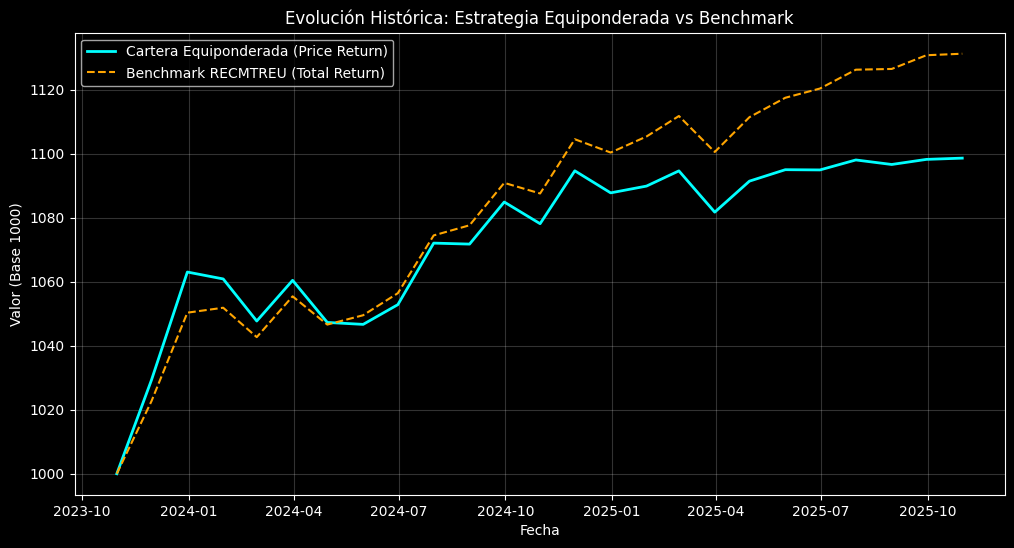

Rentabilidad Acumulada Cartera (Price Return): 9.87%
Rentabilidad Acumulada Benchmark (Total Return): 13.13%


In [20]:
# --------------------- COMPRACIÓN CON BENCHMARK Y GRÁFICO -------------------------
# Rebasamos el benchmark a 1000 en la fecha de inicio de nuestra cartera para comparar
base_benchmark = ts_benchmark.loc[cartera.index[0]]
benchmark_normalizado = (ts_benchmark / base_benchmark) * 1000

plt.figure(figsize=(12, 6))
plt.plot(cartera.index, cartera, label='Cartera Equiponderada (Price Return)', color='cyan', linewidth=2)
plt.plot(benchmark_normalizado.index, benchmark_normalizado, label='Benchmark RECMTREU (Total Return)', color='orange', linestyle='--')

plt.title('Evolución Histórica: Estrategia Equiponderada vs Benchmark')
plt.xlabel('Fecha')
plt.ylabel('Valor (Base 1000)')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

# Cálculo de rentabilidad final
rentabilidad_cartera = (cartera.iloc[-1] / 1000 - 1) * 100 # (Valor final - Valor inicial)/Valor inicial
rentabilidad_bench = (benchmark_normalizado.iloc[-1] / 1000 - 1) * 100

print(f"Rentabilidad Acumulada Cartera (Price Return): {rentabilidad_cartera:.2f}%")
print(f"Rentabilidad Acumulada Benchmark (Total Return): {rentabilidad_bench:.2f}%")

**1. ¿Qué sería lo más correcto en lugar de utilizar los precios MID?**

Lo más correcto sería utilizar los precios de ejecución, Bid y Ask, para así tener en cuenta también los costes de las transacciones. 

Por lo que he informarme, el precio MID es la media entre la oferta y la demanda, es decir, $\frac{Bid + Ask}{2}$. Esto nos da a entender que no hay costes de transacciones, por lo que de esta forma estaríamos sobreestimando la rentabilidad de nuestro algoritmo. Si en lugar de utilizar el precio MID, utilizamos el Bid/Ask, la rentabilidad de nuestro algoritmo se reduciría en gran medida, ya que además, realizamos un rebalanceo por mes.

**2. ¿Se te ocurre algún otro benchmark que se podría utilizar?**

Teniendo en cuenta que en este ejercicio hemos calculado la rentabilidad de la cartera basándonos únicamente en la variación de los precios (Price Return) por simplificación, comparar nuestros resultados con el benchmark RECMTREU, que es Total Return, resulta en una comparación injusta ya que nos penaliza al ignorar el cobro de lo cupones.

Para realizar una comparativa homogénea, podríamos usar diferentes la opción Price Return del índice RECMTREU. De esta forma, ailaríamos el efecto de la selección de activos y la evolución de precios, eliminando los efectos que genera la reinversión de cupones en el índice Total Return.



### <font color=#336699>6. Cartera mandato</font>

<style>.gray {background-color: #595959}

</style><div class="gray">

❕💬 Como adelantábamos en el enunciado, tienes el mandato de construir una cartera de como máximo **20** bonos corporativos con ese universo y una serie de restricciones y, claro, maximizando la rentabilidad total de la cartera:
- La duración de la cartera no debe superar los 3 años
- La exposición a emisiones HY no puede superar el 10% de la cartera
- No puedes invertir en deuda subordinada
- No se puede invertir en emisiones de tamaño igual o inferior a 500 millones
- No se puede invertir más de un 10% del capital en una misma emisión
- No puede haber más de un 15% de concentración en un mismo emisor
(¡OJO! No estamos teniendo en cuenta en este ejercicio si hubiera un mínimo de inversión, lo cuál sería un dato relevante tener en cuenta en un caso real)

1. Teniendo en cuenta la naturaleza que nos están pidiendo para la cartera, ¿añadirías alguna otra restricción?

2. ¿Cómo medirías el riesgo de crédito de la cartera?

3. ¿Cómo medirías el riesgo de liquidez de la cartera? ¿Se te ocurre alguna otra información que se podría utilizar aunque no se te haya dado?

4. Describe cómo habría que hacer el backtest de esta cartera, no hace falta que lo implementes en este caso

</div>

Tras investigar distintas formas para la realización de este ejercicio, la más convincente nos ha resultado mediante programación lineal. Este enfoque nos permite obtener la solución matématica óptima respetando todas las reglas propuestas. Para ello hemos usado la librería `PuLP` de Python; esta librería, a diferencia de los algoritmos iterativos o de prueba y error, nos permiten traducir las restricciones a un sistema de ecuaciones algebraicas. El solver matemático resuelve este sistema simultaneamente, garantizando que la solución obtenida es el óptimo matemático absoluto. Esto nos asegura que no existe ninguna otra combinación de activos posible que, cumpliendo las mismas restricciones, nos de una rentabilidad superior. 
Hemos configurado el problema usando la función `LpMaximize`, para poder maximizar la rentabilidad.

En Programación Lineal, definimos un Objetivo (qué queremos maximizar) y unas restricciones usando ecuaciones. Debemos tener en cuenta dos factores, las variables de decisión, la función objetivo y las restricciones.

**1. Variables de decisión**

* **Peso ($w_i$):** Una variable continua (entre 0 y 1) que representa el % del capital invertido en el bono $i$.

* **Selección ($z_i$):** Una variable binaria ($0$ o $1$).
  * **$z_i = 1$:** Compramos el bono.

  * $z_i = 0$: No compramos el bono.

**2. Función objetivo**

Queremos maximizar la rentabilidad total de la cartera. Matemáticamente es la suma del peso de cada bono multiplicado por su YTM. $$\text{Maximizar } Z = \sum (w_i \times \text{YTM}_i)$$

**3. Restricciones**

* **1. Presupuesto total:** La suma de los pesos debe dar 1 (100%). $$\sum w_i = 1$$

* **2. Máximo de 20 bonos:** La suma de las variables binarias no puede exceder 20.$$\sum z_i \le 20$$

* **3. Peso de los bonos:** Si invertimos dinero ($w_i > 0$), entonces el bono debe contar como seleccionado ($z_i = 1$). Además, ningún bono puede superar el 10% de peso.$$w_i \le 0.10 \times z_i$$(Si $z_i=0$, entonces $w_i$ se fuerza a 0. Si $z_i=1$, $w_i$ puede ser hasta 0.10).

* **4. Duración de la Cartera:** El promedio ponderado de la duración debe ser menor o igual a 3 años.$$\sum (w_i \times \text{Duración}_i) \le 3$$

* **5. High Yield (HY):** La suma de los pesos de los bonos clasificados como HY no puede superar el 10%.$$\sum_{i \in HY} w_i \le 0.10$$

* **6. Concentración por Emisor:** Para cada emisor $k$, la suma de pesos de sus bonos no puede superar el 15%.$$\sum_{i \in \text{Emisor}_k} w_i \le 0.15$$

In [30]:
from pulp import *

# ------------------------------ 1. PREPARACIÓN DE DATOS ------------------------------

df = df_universo.copy()

# A veces 'Outstanding Amount' puede venir como string o con puntos, asi se puede convertir a un numero puro (ej: 1.000.000 -> 1000000)
col_amount = 'Outstanding Amount'
if df[col_amount].dtype == object:
    df[col_amount] = df[col_amount].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False)
df[col_amount] = pd.to_numeric(df[col_amount], errors='coerce')


In [31]:
# ------------------------------ 2. FILTROS PREVIOS AL OPTIMIZADOR ------------------------------
# Definimos las máscaras de filtrado
# a. No deuda subordinada (Seniority no debe contener "Subordinated" o "Jr")
mask_seniority = ~df['Seniority'].str.contains('Subordinated|Jr', case=False, na=False)

# b. Tamaño > 500 Millones
mask_size = df['Outstanding Amount'] > 500_000_000

# c. Debe tener YTM y Duración calculados (y YTM coherente)
mask_valid = df['YTM (%)'].notna() & df['Duracion'].notna() & (df['YTM (%)'] > -100)

# Aplicamos filtros para que el modelo matemático solo considere estos
df_opt = df[mask_seniority & mask_size & mask_valid].reset_index(drop=True)

# Identificamos bonos High Yield (HY)
ratings_hy_list = ['BB+', 'BB', 'BB-', 'B+', 'B', 'B-', 'CCC+', 'CCC', 'CCC-', 'NR', 'High Yield'] 
df_opt['is_HY'] = df_opt['Rating'].apply(lambda x: 1 if x in ratings_hy_list else 0)

print(f"Bonos totales: {len(df)}. Bonos elegibles para optimizar: {len(df_opt)}")

Bonos totales: 2255. Bonos elegibles para optimizar: 1353


In [ ]:
# ------------------------------ 3. MODELADO MATEMÁTICO CON PULP ------------------------------
# Crear el problema de Maximización
prob = LpProblem("Cartera_Bonos_Maximize_YTM", LpMaximize)

# Lista de índices de los bonos elegibles
bonos = df_opt.index.tolist()



# --- VARIABLES DE DECISIÓN ---

# w[i]: Peso del bono i (continuo, entre 0 y 1)
w = LpVariable.dicts("peso", bonos, lowBound=0, upBound=1, cat='Continuous') # cat='Continuous' indica que puede ser cualquier decimal

# z[i]: Variable binaria de selección (1 si se compra, 0 si no)
z = LpVariable.dicts("seleccion", bonos, cat='Binary')



# --- FUNCIÓN OBJETIVO ---

# Maximizar la YTM ponderada de la cartera
prob += lpSum([w[i] * df_opt.loc[i, 'YTM (%)'] for i in bonos]), "Maximizar_Rentabilidad"



# --- RESTRICCIONES ---

# 1. La suma de pesos debe ser 100% (1.0)
prob += lpSum([w[i] for i in bonos]) == 1, "Presupuesto_Total"

# 2. Máximo 20 bonos en cartera
prob += lpSum([z[i] for i in bonos]) <= 20, "Max_20_Bonos"

# 3. Vinculación y Límite Individual (10%):
#    Si z[i]=0, w[i] es 0. Si z[i]=1, w[i] puede ser hasta 0.10
for i in bonos:
    prob += w[i] <= 0.10 * z[i], f"Link_Peso_Binaria_{i}"

# 4. Duración de la Cartera: Promedio ponderado <= 3 años
prob += lpSum([w[i] * df_opt.loc[i, 'Duracion'] for i in bonos]) <= 3, "Duracion_Max_3"

# 5. Suma de pesos HY <= 10%
hy_indices = df_opt[df_opt['is_HY'] == 1].index.tolist()
prob += lpSum([w[i] for i in hy_indices]) <= 0.10, "Limite_Total_HY"

# 6. Máximo 15% por emisor
emisores = df_opt['Issuer'].unique()
for emisor in emisores:
    indices_emisor = df_opt[df_opt['Issuer'] == emisor].index.tolist() # Guardamos una lista de todos los índices donde aparece ese emisor
    # Solo añadimos la restricción si el emisor tiene 2 o más bonos elegibles, ya que para un solo bono ya añadimos la restricción del 10%
    if len(indices_emisor) > 1: 
        prob += lpSum([w[i] for i in indices_emisor]) <= 0.15, f"Limite_Emisor_{emisor}" # Así nos aseguramos que aunque compremos 4 bonos de un mismo emisor, nunca supere el 15% de toda la cartera

In [ ]:
# ------------------------------ 4. RESOLUCIÓN Y ANÁLISIS ------------------------------

# Resolvemos usando el solver por defecto
status = prob.solve()

print(f"Estado de la solución: {LpStatus[prob.status]}")

if LpStatus[prob.status] == 'Optimal': # Si nos indica Optimal es que se encontro la mejor solucion posible
    resultados = []
    for i in bonos:
        peso_final = value(w[i])
        # Filtramos pesos muy pequeños (ruido numérico del solver)
        if peso_final > 0.0001: # Para evitar que coja pesos de 0.000001 
            fila = df_opt.loc[i].copy()
            fila['Peso_Final'] = peso_final
            resultados.append(fila)

    cartera_final = pd.DataFrame(resultados)
    
    # CÁLCULO DE MÉTRICAS FINALES
    if not cartera_final.empty:
        ytm_final = (cartera_final['Peso_Final'] * cartera_final['YTM (%)']).sum()
        duracion_final = (cartera_final['Peso_Final'] * cartera_final['Duracion']).sum()
        expo_hy = cartera_final[cartera_final['is_HY'] == 1]['Peso_Final'].sum()
        
        print("-" * 60)
        print(f"CARTERA GENERADA CON ÉXITO ({len(cartera_final)} bonos)")
        print("-" * 60)
        print(f"Rentabilidad (YTM) Esperada:  {ytm_final:.2f}%")
        print(f"Duración de la Cartera:       {duracion_final:.2f} años")
        print(f"Exposición a High Yield:      {expo_hy*100:.2f}%")
        print("-" * 60)
        
        # Mostrar top 10 bonos por peso
        cols_ver = ['ISIN', 'Issuer', 'Rating', 'YTM (%)', 'Duracion', 'Peso_Final']
        display(cartera_final[cols_ver].sort_values('Peso_Final', ascending=False).head(20))
    else:
        print("La solución es óptima pero la cartera está vacía (caso extraño).")

else:
    print("No se encontró solución factible. Relaja")

Estado de la solución: Optimal
------------------------------------------------------------
CARTERA GENERADA CON ÉXITO (12 bonos)
------------------------------------------------------------
Rentabilidad (YTM) Esperada:  5.38%
Duración de la Cartera:       3.00 años
Exposición a High Yield:      10.00%
------------------------------------------------------------


,ISIN,Issuer,Rating,YTM (%),Duracion,Peso_Final
27,XS1186176571,HEATHROW FUNDING LTD,BBB+,21.283701,0.300439,0.100000
97,FR0013231768,IMERYS SA,BBB-,3.220917,0.991399,0.100000
402,FR0013476090,RCI BANQUE SA,BBB,2.943653,0.997666,0.100000
527,XS2193983108,UPJOHN FINANCE BV,BBB-,4.133038,5.822770,0.100000
835,XS2421195848,AROUNDTOWN SA,NR,3.350671,1.244854,0.100000
726,XS2356041165,STELLANTIS NV,BBB,4.515512,6.773231,0.100000
796,XS2397252011,HEIMSTADEN BOSTAD TRESRY,BBB-,4.069700,5.312296,0.100000
817,XS2406914346,HIGHLAND HOLDINGS SARL,BBB,2.966351,0.928618,0.100000
1155,XS2597994065,GLOBAL PAYMENTS INC,BBB-,3.741765,4.496097,0.063538
762,XS2384269366,HEIMSTADEN BOSTAD TRESRY,BBB-,3.598284,3.508512,0.050000


##### <font color=#CC6600>Restricciones adicionales</font>

**1. Teniendo en cuenta la naturaleza que nos están pidiendo para la cartera, ¿añadirías alguna otra restricción?**

Teniendo en cuenta que se busca una cartera conservadora (duración de 3 años) y de calidad (HY<=10%), añadiría las siguientes restricciones para evitar riesgos:

* **Diversificación sectorial:** La restricción del 15% por emisor no protege contras riesgos sistemáticos de una industria. Podríamos acabar con un 80% de la cartera en bancos, y si hay una crisis bancaria la cartera se hundiría. Por lo que **ningún sector industrial puede superar el 30% de la cartera.**

* **Rating medio ponderado:** Limitar el High Yield al 10% está bien, pero el otro 90% podría ser todo BBB-, lo que dejaría la cartera al borde de ser completamente High Yield. Por lo que **el rating medio ponderado de la cartera debe ser al menos BBB+ o A-.**

* **Convexidad positiva:** Elimino bonos con opciones callable muy agresivas ya que pueden hacer pierda dinero si los tipos suben y no ganaría mucho más si los tipos bajan.



##### <font color=#CC6600>Riesgo de crédito</font>

**2. ¿Cómo medirías el riesgo de crédito de la cartera?**

Para una cartera de rentja fija corporativa, el reisgo de que el emisor no pague o que su calidad empeore y el precio caiga, se mide con otras métrica más allá de un rating.

* **DTS (Duration Times Spread):** Nos dice cuánto caerá el precio de la cartera si los spread sde crédito se amplian un porcentaje relativo. Da más peso a los bonos más largos y con mayor spread.

* **Probabilidad de Default Ponderada:** Dado que en `universo.csv` tengo la columna `PD 1YR`, calcularíamos la media ponderada de esa probabilidad para tener un número concreto.

* **Crédito VaR (Valor en Riesgo de Crédito):** Estima la pérdida máxima por migración de rating (que un bono pase de A a BBB y baje de precio) o default en un horizonte dado con un nivel de confianza.

##### <font color=#CC6600>Riesgo de liquidez</font>

**3. ¿Cómo medirías el riesgo de liquidez de la cartera? ¿Se te ocurre alguna otra información que se podría utilizar aunque no se te haya dado?**

El riesgo de liquidez es el coste o la imposibilidad de deshacer la posición rápidamente sin afectar al precio. Para medirlo se me ocurren las siguientes formas:

* **Bid-Ask Spread:** Usando las columnas `Bid Price` y `Ask Price` del CSV lo calcularía. $$Bid-Ask Spread = \frac{\text{Ask} - \text{Bid}}{\text{Mid Price}}$$
Este porcentaje es el coste inmediato de liquidez. Si la media de la cartera es 0.50%, pierdes eso automáticamente al entrar y salir. Es la métrica más directa.

* **Tiempo de liquidación:** Consiste en estimar cuantos días se tardaría en vender toda la posición sin mover el precio, basándonos en el volumen diario medio.

En cuanto a la información adicional que resultaría útil y no ha sido proporcionada nos encontraríamos:

* **Volumen Diario de Negociación (ADV):** Saber cuánto se negocia realmente ese bono al día.

* **Profundidad de Mercado:** Cuántas órdenes de compra hay en el libro de órdenes.

* **Edad de la emisión:** Los bonos recién emitidos son muy líquidos. Los antiguos suelen dejar de negociarse y se vuelven ilíquidos aunque se trate de una empresa muy grande.

##### <font color=#CC6600>Backtest</font>

**4. Describe cómo habría que hacer el backtest de esta cartera, no hace falta que lo implementes en este caso**

Para realizar un backtest riguroso de esta cartera, el proceso paso a paso sería:

**1. Definición de ventana y frecuencia:**
- Elegir el periodo.
- Definir la frecuencia de rebalanceo. Esto implica, cada vez que se rebalancee, volver a ejecutar el algoritmo para ver si la cartera sigue cumpliendo las reglas.

**2. Universo dinámico:**
- En cada fecha de rebalanceo del pasado, solo podemos elegir entre los bonos que existían y estaban vivos en esa fecha.

**3. Cálculo de retornos realista:**
- Dado que el ejercicio simplifica el uso de precios y nuestros históricos son precios de cierre o MID, asumimos la ejecución a estos precios medios. Reconocemos que esto ignora el coste de liquidez explícito (spread Bid-Ask) que tendríamos en un entorno real.
- Dado que la serie de precios históricos es Clean Price y no Total Return, el backtest mostrará la evolución del precio del activo. Se debe tener en cuenta que esto subestima la rentabilidad real acumulada frente a una estrategia que cobrara y reinvirtiera explícitamente los cupones.

**4. Gestión de Eventos:**
- Si un bono vence o es amortizado anticipadamente (called) durante el backtest, se recibe el principal (100%). Ese dinero debe reinvertirse en el siguiente revalanceo.

**5. Benchmarking:**
- Comparamos la serie temporal del valor de mi cartera contra el índice RECMTREU.
- Dado que el benchmark es un índice Total Return y nuestra serie histórica está basada en precios, es esperable que el benchmark muestre un desempeño superior en el largo plazo por el efecto de las rentas.

### <font color=#336699>7. Cobertura tipos de interés</font>

<style>.gray {background-color: #595959}

</style><div class="gray">

❕💬 Utiliza alguno de los siguientes instrumentos de los que te hemos dado para cubrir la duración (sensibilidad de tipos de interés) de la cartera que has construido según el mandato. Asume una inversión en la cartera de 10 millones:

- Futuros sobre el *Schatz* (ticker: DU1) - Duración a 01/10/2025: 1.92
- Futuros sobre el *BOBL* (ticker: OE1) - Duración a 01/10/2025: 5.44
- Futuros sobre el *BUND* (ticker: RX1) - Duración a 01/10/2025: 10

*Contract size* en todos los casos: 100,000 euros

Investiga sobre estos instrumentos antes de tomar la decisión. Razona tu elección del instrumento y el número de contratos que has decidido comprar/vender.

- ¿Qué pasaría si comprásemos/vendiésemos 100 futuros?
- ¿Se te ocurre algún otro instrumento con el que cubrir la sensibilidad a los tipos de interés de la cartera?

</div>

### <font color=#336699>8. Cobertura crédito</font>

<style>.gray {background-color: #595959}

</style><div class="gray">

❕💬 Utiliza alguno de los siguientes instrumentos de los que te hemos dado para cubrir el riesgo de crédito de la cartera que has construido según el mandato. Asume una inversión en la cartera de 10 millones:

- ITRAXX Main (ticker: ITRX EUR CDSI GEN 5Y Corp)
- ITRAXX XOVER (ticker: ITRX XOVER CDSI GEN 5Y Corp)

Estos índices cotizan en forma de spread, en puntos básicos. La sensibilidad del valor del swap (CDS) la vamos a asumir en 4,500€ al punto básico asumiendo una inversión de 10 millones.

Investiga sobre estos instrumentos antes de tomar la decisión. Razona tu elección del instrumento y el nominal que has decidido comprar/vender.

- ¿Tiene sentido plantear esta cobertura total?
- ¿Con qué otros instrumentos podrías cubrir el riesgo de crédito?

</div>

### <font color=#336699>9. Estrategia propia</font>

<style>.gray {background-color: #595959}

</style><div class="gray">

❕💬 Plantea tu propia estrategia con la información que tienes. Puede ser una estrategia direccional, de valor relativo, que hayas visto o no en clase; pero siempre razonando tu planteamiento.

</div>